In [ ]:
#pip install tensorflow pandas matplotlib pillow scikit-learn notebook jupyter

     -------------------                    179.1/350.6 MB 1.5 MB/s eta 0:01:53
Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_vendor\urllib3\response.py", line 437, in _error_catcher
    yield
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_vendor\urllib3\response.py", line 560, in read
    data = self._fp_read(amt) if not fp_closed else b""
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_vendor\urllib3\response.py", line 526, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 90, in read
    data = self.__fp.read(amt)
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\http\client.py", line 465, in read
    s = self.fp.read(amt)
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\socket.py", line 705, in readinto
    

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [8]:
dataset_path = r"C:\Users\ASUS\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage"

In [9]:
classes = os.listdir(dataset_path)

print("Number of Classes:", len(classes))
print("\nClass Names:")

for cls in classes:
    print(cls)

Number of Classes: 16

Class Names:
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus


In [10]:
class_df = pd.DataFrame(classes, columns=["Disease Class"])

class_df

,Disease Class
0,Pepper__bell___Bacterial_spot
1,Pepper__bell___healthy
2,PlantVillage
3,Potato___Early_blight
4,Potato___healthy
5,Potato___Late_blight
6,Tomato_Bacterial_spot
7,Tomato_Early_blight
8,Tomato_healthy
9,Tomato_Late_blight


In [11]:
class_df.to_csv("outputs/class_names.csv", index=False)

print("Class names saved successfully.")

Class names saved successfully.


In [12]:
import os

image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        image_count[cls] = len(os.listdir(class_path))

image_count

{'Pepper__bell___Bacterial_spot': 997,
 'Pepper__bell___healthy': 1478,
 'PlantVillage': 15,
 'Potato___Early_blight': 1000,
 'Potato___healthy': 152,
 'Potato___Late_blight': 1000,
 'Tomato_Bacterial_spot': 2127,
 'Tomato_Early_blight': 1000,
 'Tomato_healthy': 1591,
 'Tomato_Late_blight': 1909,
 'Tomato_Leaf_Mold': 952,
 'Tomato_Septoria_leaf_spot': 1771,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676,
 'Tomato__Target_Spot': 1404,
 'Tomato__Tomato_mosaic_virus': 373,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 3209}

In [13]:
count_df = pd.DataFrame(
    image_count.items(),
    columns=["Disease Class", "Number of Images"]
)

count_df

,Disease Class,Number of Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,PlantVillage,15
3,Potato___Early_blight,1000
4,Potato___healthy,152
5,Potato___Late_blight,1000
6,Tomato_Bacterial_spot,2127
7,Tomato_Early_blight,1000
8,Tomato_healthy,1591
9,Tomato_Late_blight,1909


In [14]:
count_df.to_csv("outputs/image_count.csv", index=False)

print("Image count table saved successfully.")

Image count table saved successfully.


In [15]:
total_images = count_df["Number of Images"].sum()

print("Total Classes :", len(count_df))
print("Total Images  :", total_images)

Total Classes : 16
Total Images  : 20654


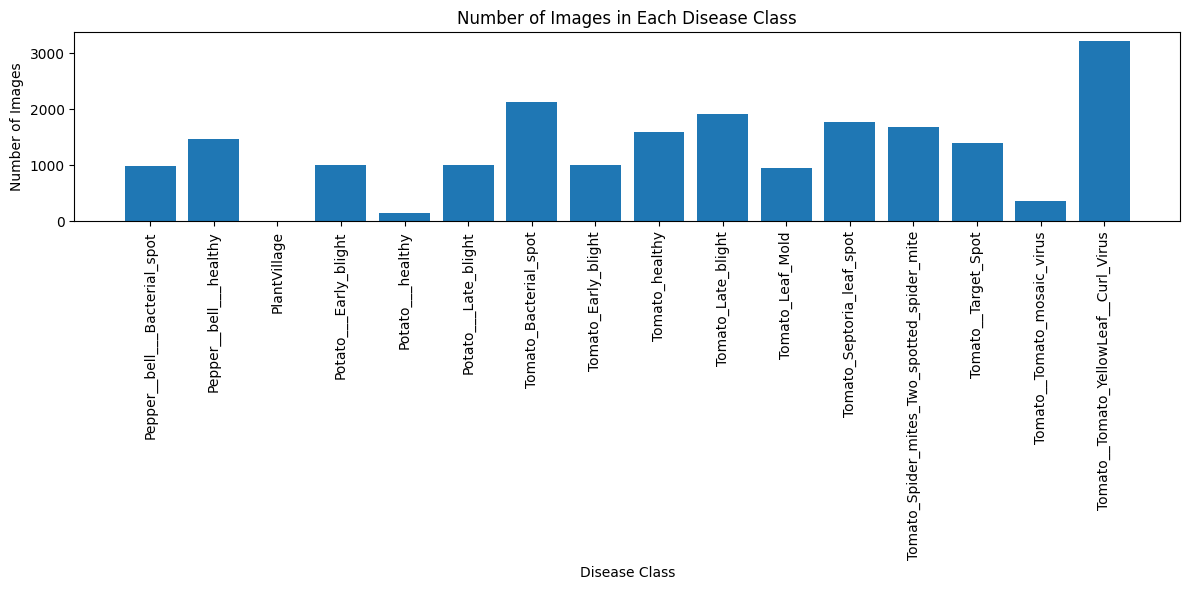

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(count_df["Disease Class"], count_df["Number of Images"])

plt.title("Number of Images in Each Disease Class")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [17]:
largest = count_df.loc[count_df["Number of Images"].idxmax()]
smallest = count_df.loc[count_df["Number of Images"].idxmin()]

print("Largest Class")
print(largest)

print("\nSmallest Class")
print(smallest)

Largest Class
Disease Class       Tomato__Tomato_YellowLeaf__Curl_Virus
Number of Images                                     3209
Name: 15, dtype: object

Smallest Class
Disease Class       PlantVillage
Number of Images              15
Name: 2, dtype: object


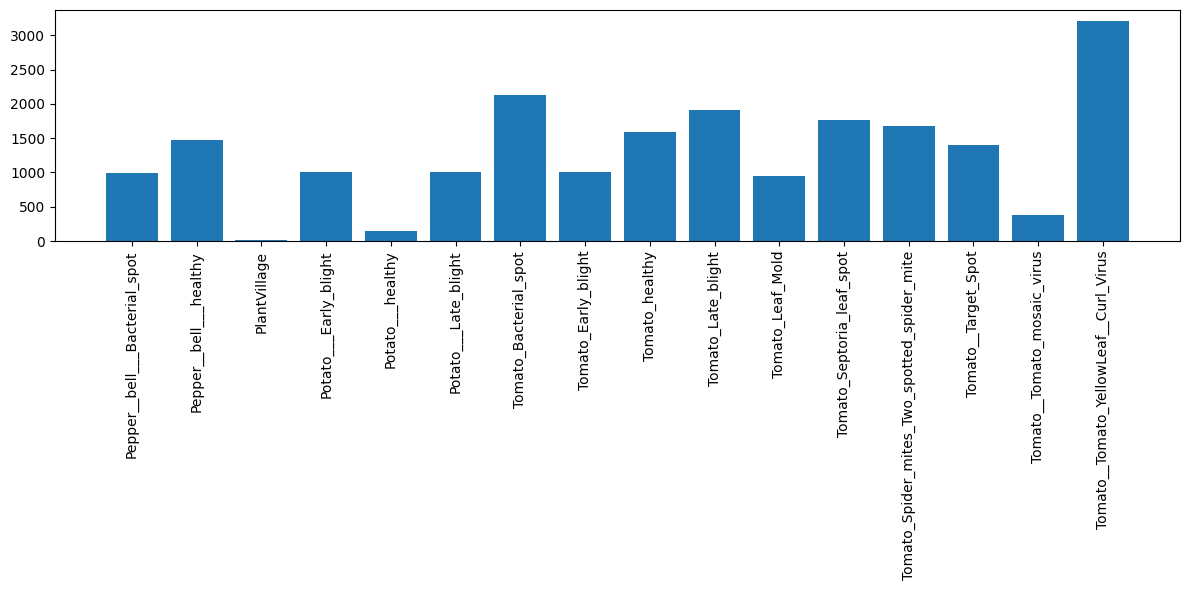

In [18]:
plt.figure(figsize=(12,6))

plt.bar(count_df["Disease Class"], count_df["Number of Images"])

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("outputs/class_distribution.png")

plt.show()

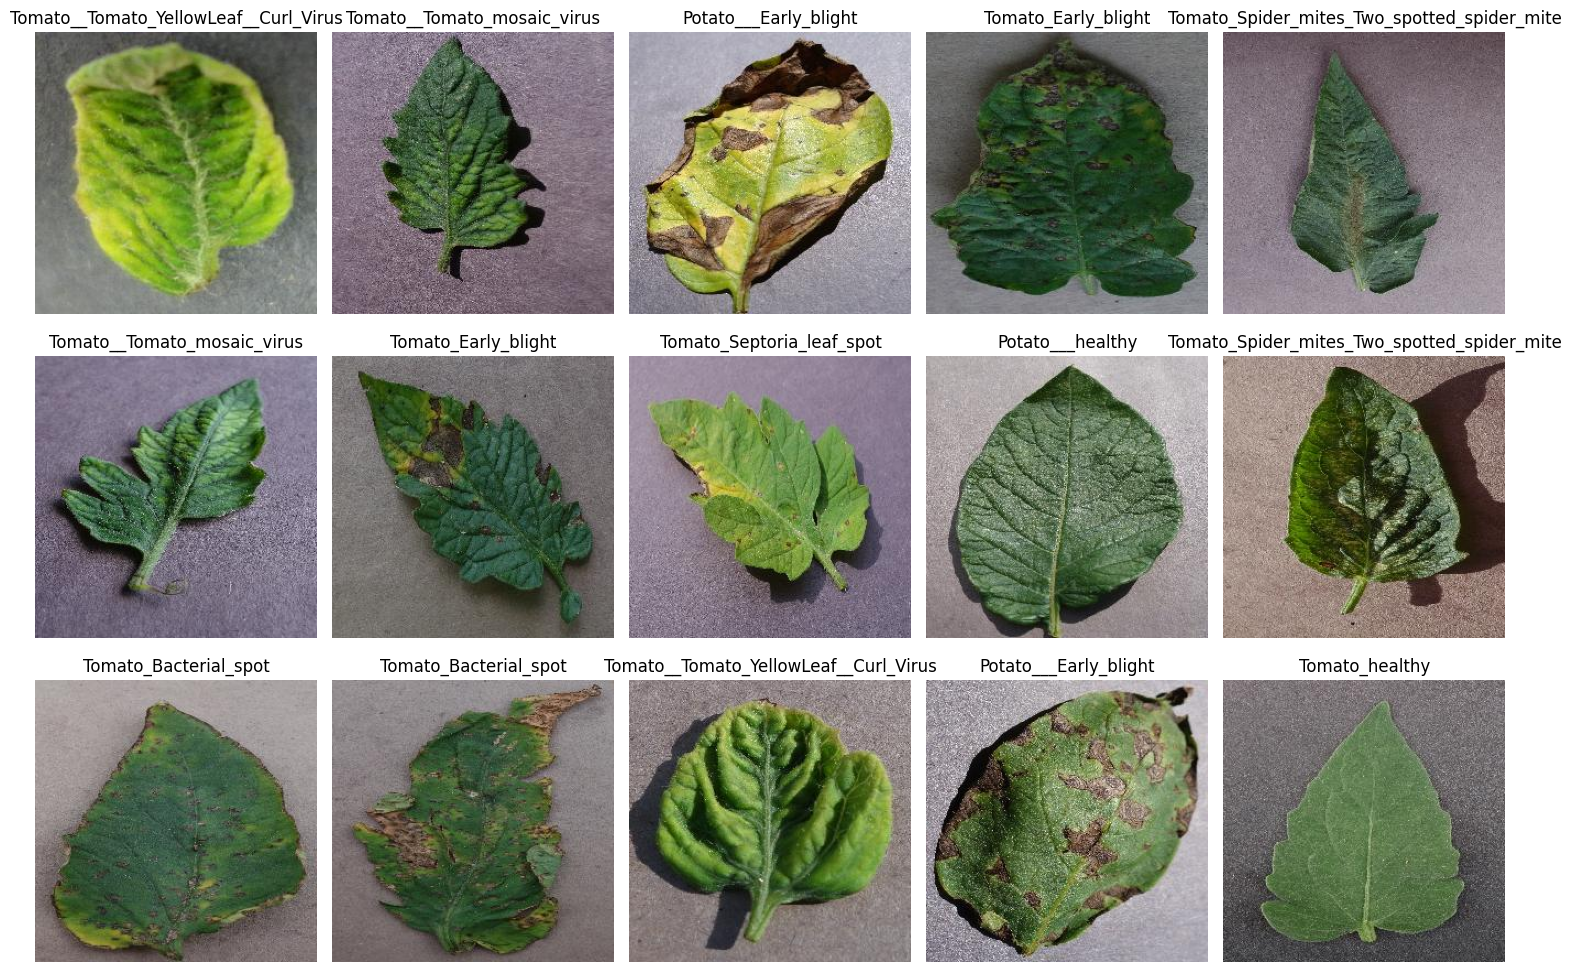

In [19]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = r"C:\Users\ASUS\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\PlantVillage"

plt.figure(figsize=(15,10))

classes = os.listdir(dataset_path)

for i in range(15):

    class_name = random.choice(classes)
    class_path = os.path.join(dataset_path, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(3,5,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
from PIL import Image
import os
import pandas as pd

sizes = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)

        except Exception:
            print("Skipped:", img_path)

size_df = pd.DataFrame(sizes, columns=["Width", "Height"])

size_df.describe()

Skipped: C:\Users\ASUS\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\PlantVillage\Tomato__Tomato_YellowLeaf__Curl_Virus\svn-r6Yb5c


,Width,Height
count,20638.0,20638.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


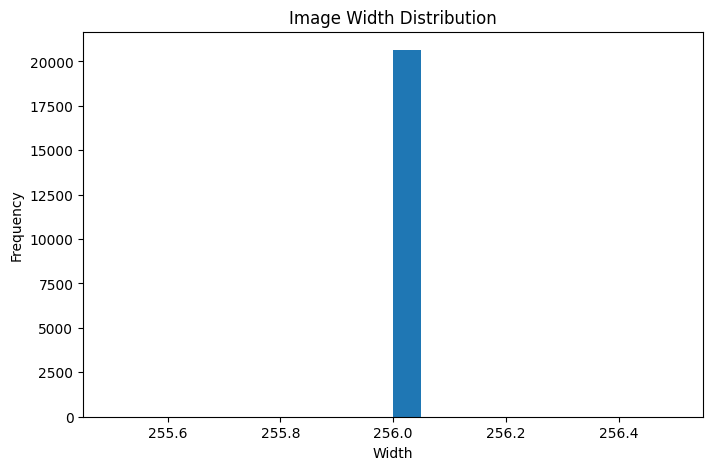

In [21]:
plt.figure(figsize=(8,5))

plt.hist(size_df["Width"], bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

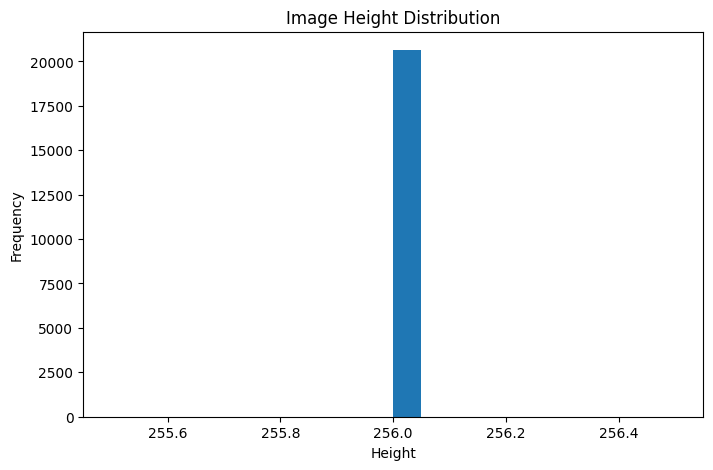

In [22]:
plt.figure(figsize=(8,5))

plt.hist(size_df["Height"], bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

In [23]:
modes = {}

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    image = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder,image))

    modes[cls] = img.mode

modes

{'Pepper__bell___Bacterial_spot': 'RGB',
 'Pepper__bell___healthy': 'RGB',
 'Potato___Early_blight': 'RGB',
 'Potato___healthy': 'RGB',
 'Potato___Late_blight': 'RGB',
 'Tomato_Bacterial_spot': 'RGB',
 'Tomato_Early_blight': 'RGB',
 'Tomato_healthy': 'RGB',
 'Tomato_Late_blight': 'RGB',
 'Tomato_Leaf_Mold': 'RGB',
 'Tomato_Septoria_leaf_spot': 'RGB',
 'Tomato_Spider_mites_Two_spotted_spider_mite': 'RGB',
 'Tomato__Target_Spot': 'RGB',
 'Tomato__Tomato_mosaic_virus': 'RGB',
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 'RGB'}

In [24]:
bad_images = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

        try:
            img = Image.open(os.path.join(folder,img_name))
            img.verify()

        except:

            bad_images.append(img_name)

print("Corrupted Images:",len(bad_images))

Corrupted Images: 1


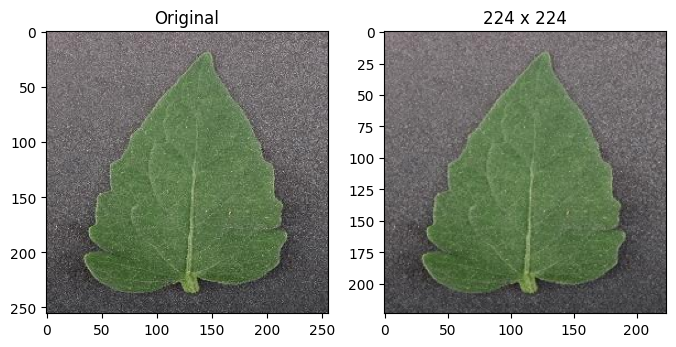

In [25]:
img = Image.open(image_path)

resized = img.resize((224,224))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

plt.imshow(img)

plt.title("Original")

plt.subplot(1,2,2)

plt.imshow(resized)

plt.title("224 x 224")

plt.show()

In [26]:
import numpy as np

img_array = np.array(resized)/255.0

print(img_array.min())

print(img_array.max())

0.00784313725490196
0.7803921568627451


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
#pip install tensorflow

In [29]:
import tensorflow as tf
import os

In [30]:
dataset_path = "C:\\Users\\ASUS\\.cache\\kagglehub\\datasets\\emmarex\\plantdisease\\versions\\1\\PlantVillage"

In [31]:
total_images = 0

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

print("Total Images:", total_images)

Total Images: 20654


In [32]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 41276 files belonging to 16 classes.
Using 33021 files for training.


In [33]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 41276 files belonging to 16 classes.
Using 8255 files for validation.


In [34]:
validation_batches = tf.data.experimental.cardinality(validation_dataset)

test_dataset = validation_dataset.take(validation_batches // 2)

validation_dataset = validation_dataset.skip(validation_batches // 2)

In [35]:
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())

print("Testing batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 1032
Validation batches: 129
Testing batches: 129


In [36]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [37]:
for images, labels in train_dataset.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32,)


In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D

num_classes = 16

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(num_classes, activation='softmax')

])

model.summary()

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,024 (42.61 MB)

 Trainable params: 11,171,024 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
#history = model.fit(
    #train_dataset,
    #validation_data=validation_dataset,
    #epochs=20,
    #callbacks=[early_stop, checkpoint]
#)

Epoch 1/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1027s 991ms/step - accuracy: 0.4925 - loss: 4.0062 - val_accuracy: 0.4933 - val_loss: 2.2062
Epoch 2/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1150s 1s/step - accuracy: 0.4993 - loss: 2.0690 - val_accuracy: 0.4924 - val_loss: 2.0139
Epoch 3/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 964s 934ms/step - accuracy: 0.4994 - loss: 1.9868 - val_accuracy: 0.4926 - val_loss: 1.9910
Epoch 4/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 894s 866ms/step - accuracy: 0.4995 - loss: 1.9782 - val_accuracy: 0.4933 - val_loss: 1.9887
Epoch 5/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 866s 839ms/step - accuracy: 0.4994 - loss: 2.0237 - val_accuracy: 0.4916 - val_loss: 1.9944
Epoch 6/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 865s 838ms/step - accuracy: 0.4994 - loss: 1.9778 - val_accuracy: 0.4914 - val_loss: 1.9950
Epoch 7/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 882s 854ms/step - accuracy: 0.4994 - loss: 1.9777 - val_accuracy: 0.4936 - val_loss: 1.9930
Epoch 8/20
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 984s 953ms/step - acc

In [41]:

model.save("final_model.keras")

print("Final model saved successfully.")

Final model saved successfully.


In [42]:

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}") 

129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 312ms/step - accuracy: 0.0426 - loss: 44.3088
Test Loss: 44.3088
Test Accuracy: 0.0426


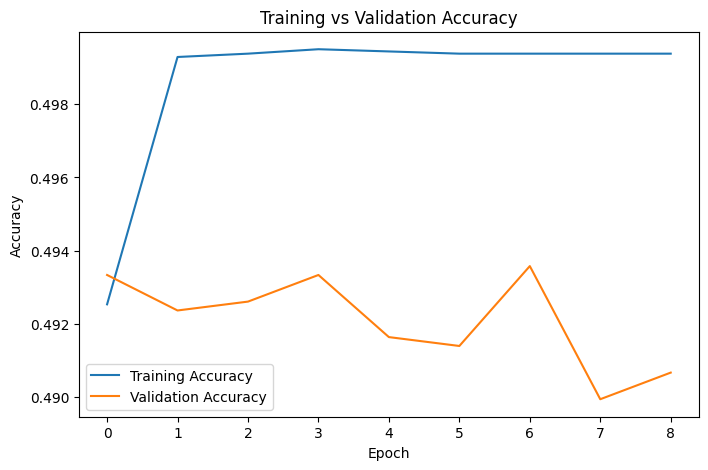

In [44]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("outputs/training_validation_accuracy.png")

plt.show()

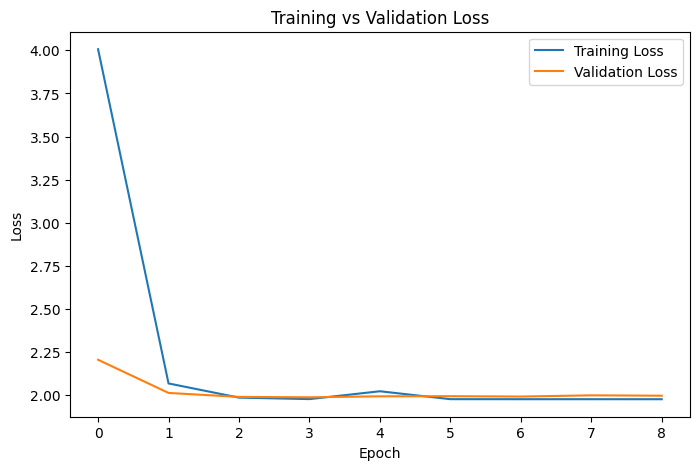

In [46]:

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("outputs/training_validation_loss.png")

plt.show()

In [47]:

print("Final Training Accuracy :", history.history['accuracy'][-1])
print("Final Validation Accuracy :", history.history['val_accuracy'][-1])
print("Final Test Accuracy :", test_accuracy)

Final Training Accuracy : 0.4993791878223419
Final Validation Accuracy : 0.49067118763923645
Final Test Accuracy : 0.5138081312179565


In [44]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,032 (9.88 MB)

 Trainable params: 332,048 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Transfer Learning model compiled successfully.")

Transfer Learning model compiled successfully.


In [49]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_dataset)

print(f"Transfer Learning Test Loss: {transfer_loss:.4f}")
print(f"Transfer Learning Test Accuracy: {transfer_accuracy:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 74s 532ms/step - accuracy: 0.0194 - loss: 3.1917
Transfer Learning Test Loss: 3.1917
Transfer Learning Test Accuracy: 0.0194


In [50]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Learning rate updated to 0.0001")

Learning rate updated to 0.0001


In [51]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Last 20 MobileNetV2 layers unfrozen for fine-tuning.")

Last 20 MobileNetV2 layers unfrozen for fine-tuning.


In [52]:
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")

Fine-tuning model compiled.


In [ ]:
#history_finetune = transfer_model.fit(
    #train_dataset,
    #validation_data=validation_dataset,
    #epochs=5,
    #callbacks=[early_stop, checkpoint]
#)

Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1044s 995ms/step - accuracy: 0.4663 - loss: 1.8661 - val_accuracy: 0.4902 - val_loss: 1.7593
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 847s 764ms/step - accuracy: 0.4851 - loss: 1.4890 - val_accuracy: 0.4902 - val_loss: 1.3602
Epoch 3/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 769s 745ms/step - accuracy: 0.4871 - loss: 1.3555 - val_accuracy: 0.4756 - val_loss: 1.2161
Epoch 4/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 783s 759ms/step - accuracy: 0.4843 - loss: 1.2826 - val_accuracy: 0.4597 - val_loss: 1.1611
Epoch 5/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 769s 726ms/step - accuracy: 0.4894 - loss: 1.2228 - val_accuracy: 0.4531 - val_loss: 1.1306


In [53]:
fine_loss, fine_accuracy = transfer_model.evaluate(test_dataset)

print(f"Fine-Tuned Test Loss: {fine_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {fine_accuracy:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 77s 559ms/step - accuracy: 0.0191 - loss: 3.1944
Fine-Tuned Test Loss: 3.1944
Fine-Tuned Test Accuracy: 0.0191


In [57]:
transfer_model.save("mobilenet_final.keras")

print("Fine-tuned model saved successfully.")

Fine-tuned model saved successfully.


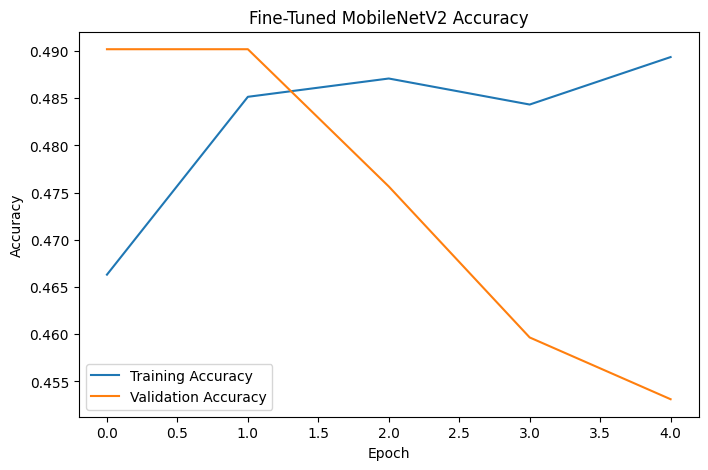

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_finetune.history["accuracy"], label="Training Accuracy")
plt.plot(history_finetune.history["val_accuracy"], label="Validation Accuracy")

plt.title("Fine-Tuned MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("outputs/fine_tuned_accuracy.png")

plt.show()

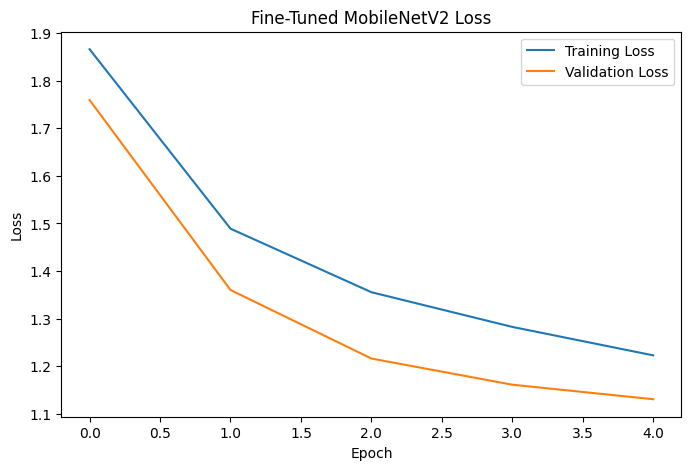

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history_finetune.history["loss"], label="Training Loss")
plt.plot(history_finetune.history["val_loss"], label="Validation Loss")

plt.title("Fine-Tuned MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("outputs/fine_tuned_loss.png")

plt.show()

In [50]:
print("Fine-Tuned Training Accuracy :", history_finetune.history['accuracy'][-1])
print("Fine-Tuned Validation Accuracy :", history_finetune.history['val_accuracy'][-1])
print("Fine-Tuned Test Accuracy :", fine_accuracy)

Fine-Tuned Training Accuracy : 0.48935526609420776
Fine-Tuned Validation Accuracy : 0.4531136453151703
Fine-Tuned Test Accuracy : 0.4893410801887512


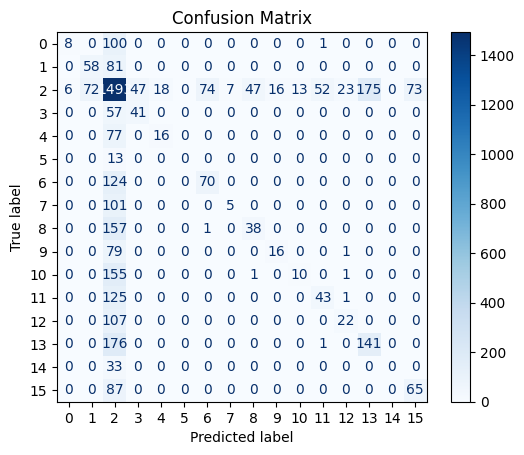

In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = transfer_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history_finetune.history)
history_df.to_csv("outputs/mobilenet_training_history.csv", index=False)

print("Training history saved successfully.")

In [68]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\ASUS\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\PlantVillage\Potato___Early_blight\0ddd62cd-a999-4d58-a8f1-506e1004a595___RS_Early.B 8041.JPG"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(img_array)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Disease:", classes[predicted_class])
print("Confidence Score:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Predicted Disease: Potato___Early_blight
Confidence Score: 0.85532


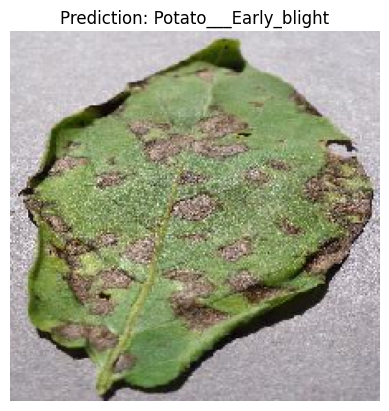

In [69]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {classes[predicted_class]}")
plt.axis("off")
plt.show()

In [62]:
transfer_model.save("../models/mobilenet_final.keras")

print("Model saved successfully.")

Model saved successfully.
